# Part 4 - Tabular Data (MiniBooNE Particle Identification)
Neural networks, especially CNNs, work extremely well on images. However, on tabular data, they are not as effective (see [this paper](https://proceedings.neurips.cc/paper_files/paper/2022/hash/0378c7692da36807bdec87ab043cdadc-Abstract-Datasets_and_Benchmarks.html)). Tabular data has columns of features which can have different data types like numerical or categorical values.

In this task, the goal is to achieve well performing classifier on the tabular [MiniBoone dataset](https://archive.ics.uci.edu/dataset/199/miniboone+particle+identification). You can reuse all your code from part 3.

In [1]:
%load_ext autoreload
%autoreload 2
import requests
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

import time

from collections import Counter

import pandas as pd
from scipy.io import arff

from Part03.device_management import get_device

# Download MiniBooNE (ARFF)
download_data = [{
    "url": "https://www.dropbox.com/scl/fi/ht6ybxai15nzuf6jqczys/MiniBooNE.arff?rlkey=v69auyh8866mew4j02cet4b5m&st=nt0w9d74&dl=1",
    "file": "MiniBooNE.arff"
}]

root = Path("raw_miniboone")
root.mkdir(parents=True, exist_ok=True)
for d in download_data:
    p = root / d["file"]
    if not p.exists():
        r = requests.get(d["url"], timeout=60)
        r.raise_for_status()
        p.write_bytes(r.content)

# Load DataFrame
miniboone_df = pd.DataFrame(arff.loadarff(root / "MiniBooNE.arff")[0])

DEVICE = get_device()

In [2]:
display(miniboone_df.head())
print('Means:')
display(pd.DataFrame(miniboone_df.drop('signal', axis=1).mean()).transpose().head())
print(f"Unique signal values: {miniboone_df['signal'].unique()}")

,signal,ParticleID_0,ParticleID_1,ParticleID_2,ParticleID_3,ParticleID_4,ParticleID_5,ParticleID_6,ParticleID_7,ParticleID_8,...,ParticleID_40,ParticleID_41,ParticleID_42,ParticleID_43,ParticleID_44,ParticleID_45,ParticleID_46,ParticleID_47,ParticleID_48,ParticleID_49
0,b'True',2.59413,0.468803,20.6916,0.322648,0.009682,0.374393,0.803479,0.896592,3.59665,...,101.174,-31.3730,0.442259,5.86453,0.000000,0.090519,0.176909,0.457585,0.071769,0.245996
1,b'True',3.86388,0.645781,18.1375,0.233529,0.030733,0.361239,1.069740,0.878714,3.59243,...,186.516,45.9597,-0.478507,6.11126,0.001182,0.091800,-0.465572,0.935523,0.333613,0.230621
2,b'True',3.38584,1.197140,36.0807,0.200866,0.017341,0.260841,1.108950,0.884405,3.43159,...,129.931,-11.5608,-0.297008,8.27204,0.003854,0.141721,-0.210559,1.013450,0.255512,0.180901
3,b'True',4.28524,0.510155,674.2010,0.281923,0.009174,0.000000,0.998822,0.823390,3.16382,...,163.978,-18.4586,0.453886,2.48112,0.000000,0.180938,0.407968,4.341270,0.473081,0.258990
4,b'True',5.93662,0.832993,59.8796,0.232853,0.025066,0.233556,1.370040,0.787424,3.66546,...,229.555,42.9600,-0.975752,2.66109,0.000000,0.170836,-0.814403,4.679490,1.924990,0.253893


Means:


,ParticleID_0,ParticleID_1,ParticleID_2,ParticleID_3,ParticleID_4,ParticleID_5,ParticleID_6,ParticleID_7,ParticleID_8,ParticleID_9,...,ParticleID_40,ParticleID_41,ParticleID_42,ParticleID_43,ParticleID_44,ParticleID_45,ParticleID_46,ParticleID_47,ParticleID_48,ParticleID_49
0,1.251799,-2.107551,123.795041,-3.312518,-3.585353,-3.434412,-2.627901,-2.773691,-0.15568,-3.421357,...,141.180058,-25.225963,-2.863924,2.393149,-3.585605,-3.416491,-3.753232,-0.744964,-1.987056,-3.364752


Unique signal values: [b'True' b'False']


In [3]:
# Convert (map) loaded bytes (corresponding to strings "True" and "False") to real bool True and False
# If cell is rerun, we want to keep bool True and False as is
miniboone_df['signal'] = miniboone_df['signal'].map({
    b"True": True,
    b"False": False,
    True: True,
    False: False
})

total = len(miniboone_df)

print(f'Signal values and counts:')
for key, value in Counter(miniboone_df['signal']).items():
    frac = value / total
    name = f'{key}:'
    print(f'  {name:<6} {value}/{total} = {frac:.3%}')

Signal values and counts:
  True:  36499/130064 = 28.062%
  False: 93565/130064 = 71.938%


## 4.1 Familiarize Yourself with the Data
Read the dataset description and analyze the data.
- Identify and filter out invalid samples: Locate all the rows where all features (columns) have the value $-999$. Remove them.
- Split the filtered data into training and testing sets. Use $20\%$ of the data for testing and set the `random_state` to $42$. Use the [train_test_split function from scikit-learn](https://scikit-learn.org/1.5/modules/generated/sklearn.model_selection.train_test_split.html).
- Which normalization method would you use for this dataset? Why?
- Which metrics would you use to evaluate the model?

---

#### **Filtering and Splitting**

Filtering out the invalid samples is done with simple pandas data frame operations (see below).

Splitting the data is also simply done using the scikit implementation.

#### **Normalizing**

To normalize the data, we decided to normalize over each feature (column) separately.
This is because we have no reason to assume the features have relations to each other.
We see this already in the means of the `ParticleID_i` columns ($i = 0, 1, 2$) (see above).
The means of the first values are about $1$, $-2$ and $124$, showing that not even the order of magnitude is comparable.
Normalizing over all columns at the same time with one average would "destroy" or "wash out" the features with small values.
Therefore, we normalize each feature separately, leaving us with $50$ different means and standard deviations - one for each feature column.
We print these below to check our code.

#### **Model Evaluation Metrics**

Because the dataset is unbalanced (some classes are more frequent in the dataset than others), accuracy is not the best way to score a classifier.
Always guessing the more likely class will already achieve a "good" accuracy, even though the classical/neural algorithm has not "learned" anything.

Depending on how important/costly false positives and negatives are, recall or precision can be used to evaluate how good a classifier is.

Recall is the number of true positives divided by positives in the dataset: $\text{recall} = \frac{\mathrm{TP}}{\mathrm{TP} + \mathrm{FN}}$.
It reflects how good/bad the model is at detecting positives when the item to classify is positive.

Precision is the number of true positives divided by the total number classified as positive: $\text{precision} = \frac{\mathrm{TP}}{\mathrm{TP} + \mathrm{FP}}$.
This is a useful statistic when it is most important to avoid false positives, as it being too low will show that the model is over-classifying as positive and making too many false positives.

In this case, we do not really have a preference for which mistakes are worse, so it would be useful to use the $F$-score as the evaluation statistic.
This score is the harmonic mean of the recall and precision, so maximizing this balances the mistakes of the algorithm out.
$$
F = 2 \frac{\mathrm{precision} \cdot \mathrm{recall}}{\mathrm{precision} + \mathrm{recall}}
$$

$F$-score and accuracy seem like the best metrics to use for model evaluation.
In the following tasks we are given a target accuracy, so we will use accuracy as the evaluation metric.


In [4]:
# get columns except for first (signal) column
particleID_cols = miniboone_df.columns[1:]
# identify invalid samples
mask_is_invalid = (miniboone_df[particleID_cols].eq(-999).all(axis=1))
# filter out invalid samples
filtered_df = miniboone_df[~mask_is_invalid]

train_dataset, test_dataset = train_test_split(filtered_df, test_size=0.2, random_state=42)

print(f'Indices of invalid values:\n{mask_is_invalid[mask_is_invalid].index}')

print(f'Original: {filtered_df.shape}')
print(f'Training: {train_dataset.shape}')
print(f'Testing:  {test_dataset.shape}')

Indices of invalid values:
Index([ 15610,  15758,  19652,  23229,  23632,  24094,  24517,  27271,  27374,
        31832,
       ...
       128354, 128407, 128532, 128747, 128757, 128993, 129265, 129623, 129687,
       130043],
      dtype='int64', length=468)
Original: (129596, 51)
Training: (103676, 51)
Testing:  (25920, 51)


In [5]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()

y_train = torch.tensor(train_dataset['signal'].to_numpy(), dtype=torch.long)
y_test = torch.tensor(test_dataset['signal'].to_numpy(), dtype=torch.long)

X_train = torch.tensor(standard_scaler.fit_transform(train_dataset[particleID_cols]), dtype=torch.float32)
X_test = torch.tensor(standard_scaler.transform(test_dataset[particleID_cols]), dtype=torch.float32)

train_dataloader = DataLoader(TensorDataset(X_train, y_train), batch_size=128, shuffle=True, num_workers=4)
test_dataloader = DataLoader(TensorDataset(X_test, y_test), batch_size=128, shuffle=True, num_workers=4)

# check shapes of normalization parameters, see that we are normalizing over each column
print(f'Means shape:              {standard_scaler.mean_.shape}')
print(f'Standard Deviation shape: {standard_scaler.scale_.shape}')

Means shape:              (50,)
Standard Deviation shape: (50,)


## 4.2 Classical Machine Learning
- Try to achieve a high classification accuracy using non-neural network methods.
You should aim for at least $0.937$ accuracy.
Discuss the results.

---

We chose different classical classifiers to try and achieve a $0.937$ accuracy on the MiniBooNE dataset.
The k-NN, Decision Tree, Random Forest and HGBC algorithms were used, with their implementations imported from the python scikit-learn library.


#### **Decision Tree**

A Decision Tree algorithm works by finding decision criteria to repeatedly split the training data into subsets.
The criteria are optimized to maximally reduce some measure of how "mixed" the classes are in the subsets.
This measure is usually the Gini impurity $G$, but it can also be the entropy $S$ of the subset (in the sense of information).
They quantify how "uncertain" we are about the classes contained in the subset.
Optimizing them prioritizes splitting criteria which separate classes in the best way possible.
$$
G = 1 - \sum \limits_{i = 1}^{N} p_i^2 \\
S = - \sum \limits_{i = 1}^{N} p_i \log (p_i)
$$
$N$ is the number of classes and $p_i$ is the probability of a sample in the subset being of the class $i$ (fractional frequency).

Usually the Gini impurity is used, as it is somewhat less computationally expensive than the calculation of logarithms for the entropy.
We kept this default in our code.

The repeated splitting is theoretically continued until subsets only contain one class.
Then we can assign that decision path to that class.
In practice, a maximum depth is decided upon to reduce computation time, and the decision path is assigned the class of the majority of the resulting subset.

The optimized splitting criteria are then applied to the training data to classify them according to which subset they end up in.

As can be seen in the code, the decision tree already takes a random state input.
This is to decide on criteria in the case of ties in the optimization process.

#### **Random Forest**

Following on from the decision tree algorithm we can run the algorithm multiple times on different randomly selected subsets of the training data to calculate different decision trees.
At each splitting criteria, only some of the features are randomly chosen to be relevant, reducing compute time.

This becomes a Random Forest classifier.
Given a test data point, all the generated decision trees are run on it.
The final classification is decided upon by a majority vote of all individual decision tree classifications.

#### **HGBC**

We also decided to use the Histogram-based Gradient Boosting Classification Tree algorithm (HGBC) from scikit-learn.
This method also relies on decision trees, but applies gradient boosting to improve their accuracy further.
Gradient boosting uses multiple decision trees, but they are not optimized independently.
Instead, each tree is created specifically to improve upon and correct the mistakes of the previous decision tree.
The next trees are no longer optimized to classify into the original classes.
Instead, they classify samples towards different corrections to the predictions of the original classifier tree.

The histogram version of this specific algorithm is a fast implementation of gradient boosting.
The continuous features are grouped into finite numbers of bins so that less splitting criteria must be tested.


#### **Classification Benchmark**

Below we apply the explained classification algorithms to the MiniBooNE dataset.
The accuracy score and runtimes are shown in bar charts.

We see that with the selected hyperparameters, only the HGBC algorithm achieves the target accuracy.
This is clearly the best of the tested algorithms for this classification task, as it also quite good in terms of runtime.

While the training/optimizing of the decision trees in the HGBC model takes some time, it runs quite fast when evaluating test data.
This is because only simple criteria need to be checked to classify a test data point.

The k-NN algorithm performs somewhat worse on the task, with swapped behavior in terms of training and testing runtime compared with the HGBC algorithm.
The training is simply saving the dataset, but evaluating on test data requires computing lots of distances in high dimensional vector spaces.
As was explained in previous parts, even though scikit is well optimized, this can be computationally expensive, especially with large training datasets.

The decision tree and random forest algorithms are both worse in terms of accuracy, with the random forest also taking much more time to train.
Higher runtime along with lower accuracy means we do not recommend these algorithms for the task.

Out of the tested classical algorithms, we recommend HGBC the most, because training runtime is not as important as testing runtime once the classifier is applied to the real world.
Over time, the testing runtime cost of a model such as k-NN adds up, while the longer training time for the HGBC only happens once and it saves time repeatedly with the lower testing runtime.


In [6]:
from tqdm import tqdm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

classifiers = [
    ('k-nn', KNeighborsClassifier(n_neighbors=5)),
    ('Decision Tree', DecisionTreeClassifier(max_depth=7, random_state=1)),
    ('Random Forest', RandomForestClassifier(n_estimators=200, max_depth=7, max_features=20)),
    ('HGBC', HistGradientBoostingClassifier(max_iter=1000, learning_rate=0.1, max_depth=5))
]

results: list[dict] = []
for (name, clf) in tqdm(classifiers):
    tr_st = time.time()
    clf.fit(X_train, y_train)
    tr_et = time.time()
    te_st = time.time()
    score = clf.score(X_test, y_test)
    te_et = time.time()
    results.append({
        'name': name,
        'accuracy': score,
        'training_runtime': tr_et - tr_st,
        'testing_runtime': te_et - te_st
    })

df_classical = pd.DataFrame(results)
display(df_classical.style.hide(axis='index'))

100%|██████████| 4/4 [03:40<00:00, 55.05s/it]


name,accuracy,training_runtime,testing_runtime
k-nn,0.929051,0.014500,1.814978
Decision Tree,0.901890,4.291258,0.003155
Random Forest,0.917593,209.565109,0.231854
HGBC,0.944329,4.140947,0.102904


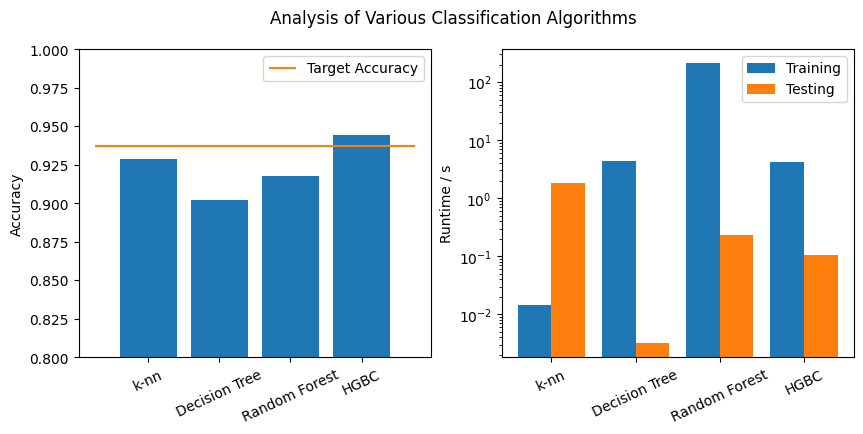

In [7]:
from Part04.classifier_analysis import clf_analysis_plots

target_accuracy = 0.937

fig, axes = clf_analysis_plots(df_classical, target_accuracy, figsize=(2*5, 4))
fig.suptitle('Analysis of Various Classification Algorithms')
plt.show()

## 4.3 Neural Networks
- Try to get a high classification accuracy using neural networks.
- See how your neural networks perform compared to your previously used methods.

---

We implement a similar MLP architecture as we used before in Part 3.
Of course, we adapt the input and output layer to match the now $50$ input channels and $2$ (binary one-hot encoding) outputs.
We also train the model very similarly to before, making sure to track the training runtime and measure the test accuracy at the end of the learning process.
Evaluating the model afterward on the test dataset, we concatenate the neural network performance statistics with the classical algorithm analysis from before.

These are finally graphed together at the end for comparison.
The training and the testing for a neural network definitely require more computing power/time than the classical methods.
However, in this case it does lead to better accuracy on the test dataset.

In the case of the neural network, the training time heavily depends on how many epochs are chosen for training.
As can be seen in the graph of accuracy during training, for this network the epoch number could be halved to correspondingly half the runtime.
While this sacrifices some accuracy, the model would still be above the target performance.
However, this approach is dependent on how well the model can be trained, its complexity and the training dataset size.
Also, reducing training epochs will not change the runtime on test data or during real world application of the model.

Generally, neural networks do take more computing power than classical algorithms, so they must be applied wisely and with the correct architecture for the task in order to get the most out of their potentially increased accuracy.

In [8]:
from Part03.NN_training import test, training_loop, loss_and_accuracy_plot
from Part04 import MLP_implementation as MLP

epochs = 14

MLP_model = MLP.Neural_Network().to(DEVICE)
print(MLP_model)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(MLP_model.parameters(), lr=1e-3)

tr_st = time.time()
results = training_loop(
    MLP_model,
    train_dataloader,
    test_dataloader,
    loss_fn,
    optimizer,
    epochs=epochs,
    DEVICE=DEVICE
)
tr_et = time.time()

df_nn = pd.DataFrame(results)

Neural_Network(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=50, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.4, inplace=False)
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)


  0%|          | 0/14 [00:00<?, ?it/s]

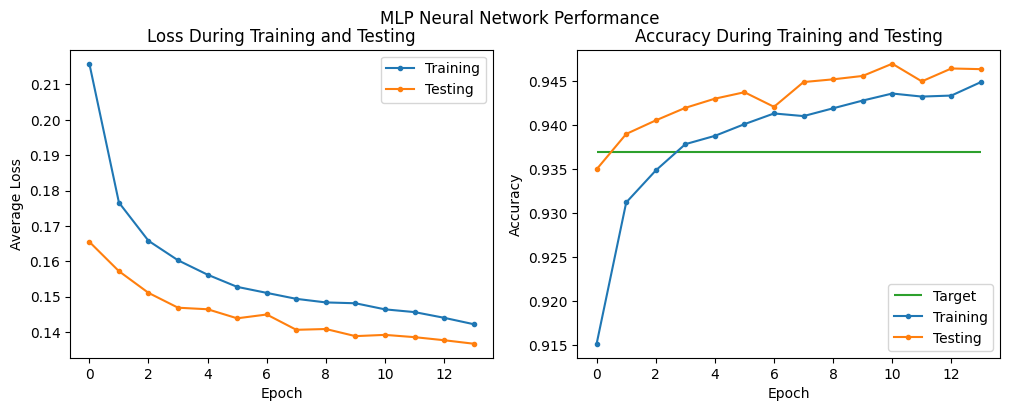

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(6*2, 4))
axes[1].hlines(target_accuracy, 0, epochs-1, color='tab:green', label='Target')
loss_and_accuracy_plot(axes, df_nn)
fig.suptitle('MLP Neural Network Performance')

plt.show()

In [10]:
te_st = time.time()
result = test(test_dataloader, MLP_model, loss_fn, DEVICE)
te_et = time.time()

# get data for nn after training, put on end of df_classical, then plot that
df_nn_final = [{
    'name': 'MLP NN',
    'accuracy': result['test_accuracy'],
    'training_runtime': tr_et - tr_st,
    'testing_runtime': te_et - te_st
}]

df = pd.concat([df_classical, pd.DataFrame(df_nn_final)])
df.style.hide(axis='index')

name,accuracy,training_runtime,testing_runtime
k-nn,0.929051,0.014500,1.814978
Decision Tree,0.901890,4.291258,0.003155
Random Forest,0.917593,209.565109,0.231854
HGBC,0.944329,4.140947,0.102904
MLP NN,0.946373,51.478262,1.462392


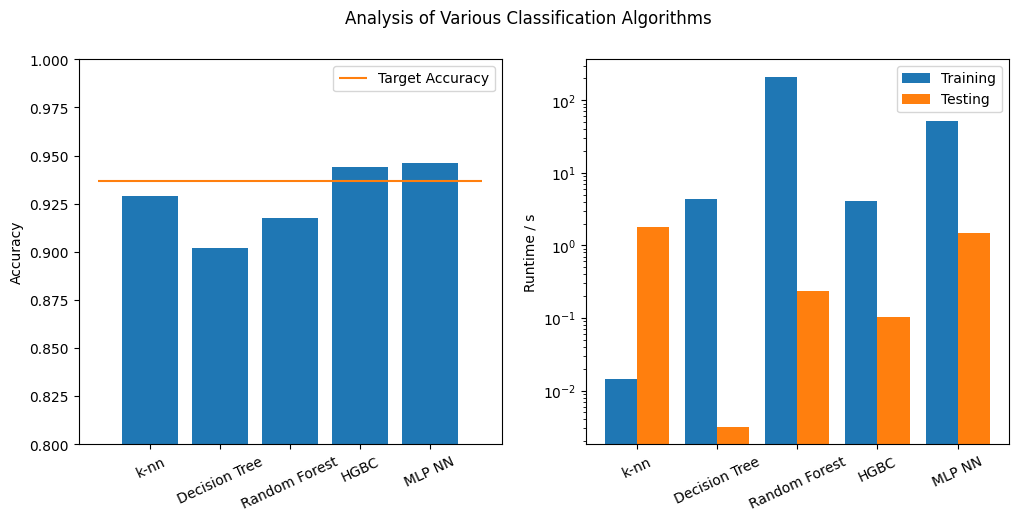

In [11]:
fig, axes = clf_analysis_plots(df, target_accuracy, figsize=(2*6, 5))
fig.suptitle('Analysis of Various Classification Algorithms')
plt.show()